✅ Найдено R-пиков: 7041
   ЧСС: 69.5 bpm


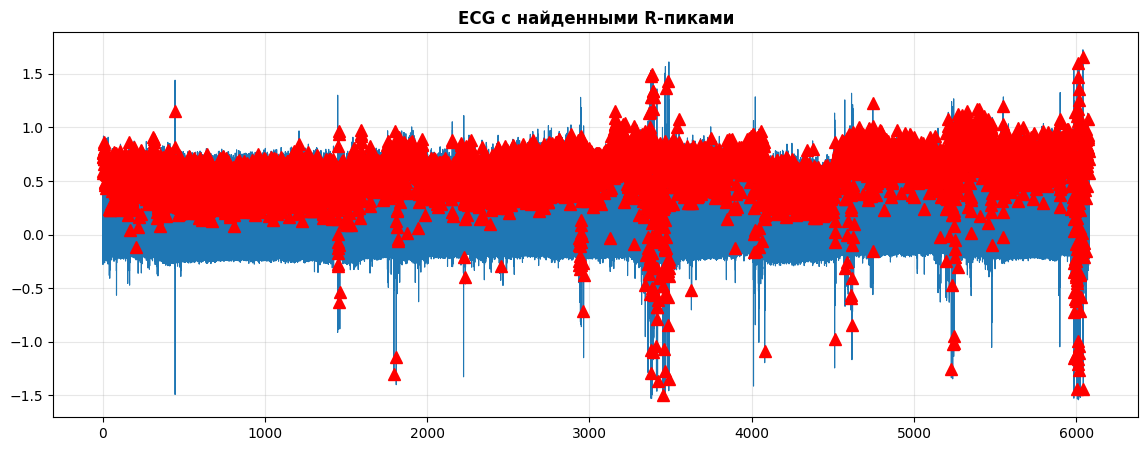

In [2]:
import pickle
import numpy as np
from scipy.signal import butter, sosfiltfilt, find_peaks
import matplotlib.pyplot as plt

# Загрузка и фильтрация
with open('model/wesad/S2/S2.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

ecg_raw = data['signal']['chest']['ECG'].flatten()
sos = butter(4, [0.5, 100], btype='band', fs=700, output='sos')
ecg_filtered = sosfiltfilt(sos, ecg_raw)

# ПОИСК R-ПИКОВ (Pan-Tompkins)
sos2 = butter(2, [5, 15], btype='band', fs=700, output='sos')
ecg_band = sosfiltfilt(sos2, ecg_filtered)
ecg_squared = ecg_band ** 2
window_size = int(0.15 * 700)
ecg_integrated = np.convolve(ecg_squared, np.ones(window_size) / window_size, mode='same')
threshold = np.mean(ecg_integrated) + 0.5 * np.std(ecg_integrated)
r_peaks, _ = find_peaks(ecg_integrated, height=threshold, distance=int(0.4 * 700))

print(f"✅ Найдено R-пиков: {len(r_peaks)}")
print(f"   ЧСС: {(len(r_peaks) / (len(ecg_filtered)/700)) * 60:.1f} bpm")

# Визуализация
fig, ax = plt.subplots(figsize=(14, 5))
time = np.arange(len(ecg_filtered)) / 700
ax.plot(time, ecg_filtered, linewidth=0.8)
ax.plot(time[r_peaks], ecg_filtered[r_peaks], 'r^', markersize=8)
ax.set_title('ECG с найденными R-пиками', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.show()
